In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


Primeras 5 filas del dataset:


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal



Estadísticas descriptivas:


,dst_port,bytes_sent,bytes_recv,duration_sec,packets
count,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04
mean,5272.963700,2.815289e+07,4.124360e+05,447.154662,1.605501e+04
std,7348.395782,3.115671e+08,1.964278e+06,4530.488171,1.672859e+05
min,21.000000,1.500000e+01,0.000000e+00,0.000000,1.000000e+00
25%,53.000000,5.544000e+03,1.328800e+04,8.507500,5.000000e+00
50%,3389.000000,2.233900e+04,5.529050e+04,21.435000,2.400000e+01
75%,8080.000000,9.478175e+04,2.213258e+05,44.145000,1.100000e+02
max,65460.000000,4.987050e+09,8.155783e+07,83028.150000,2.939448e+06


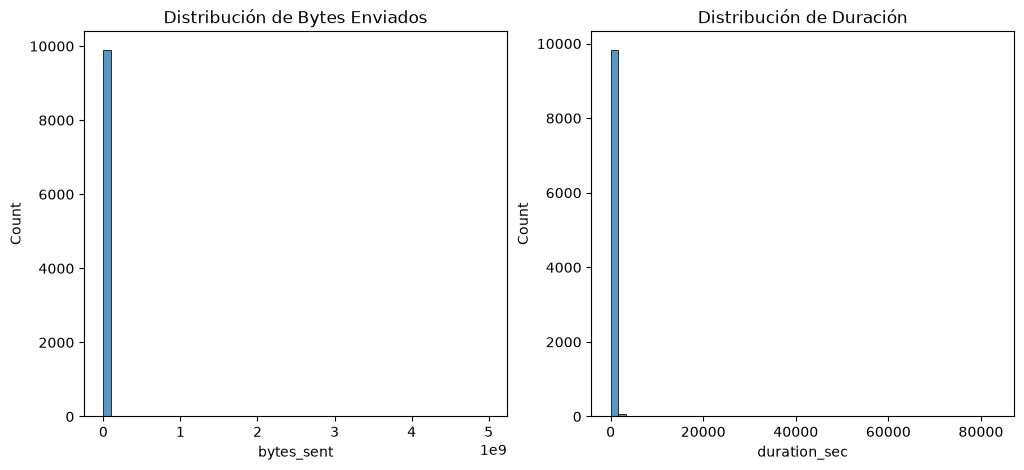

In [4]:
# Carga y muestra los primeros datos
df = pd.read_csv('network_traffic.csv')
print("Primeras 5 filas del dataset:")
display(df.head())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())

# Feature Engineering
df['ratio_bytes'] = df['bytes_sent'] / (df['bytes_recv'] + 1)
df['bytes_por_segundo'] = df['bytes_sent'] / (df['duration_sec'] + 1)

# Visualización (Histogramas)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['bytes_sent'], bins=50)
plt.title("Distribución de Bytes Enviados")

plt.subplot(1, 2, 2)
sns.histplot(df['duration_sec'], bins=50)
plt.title("Distribución de Duración")
plt.show()

Modelo entrenado exitosamente.

Reporte de Clasificación:
              precision    recall  f1-score   support

          -1       0.72      0.72      0.72       500
           1       0.99      0.99      0.99      9500

    accuracy                           0.97     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.97      0.97      0.97     10000



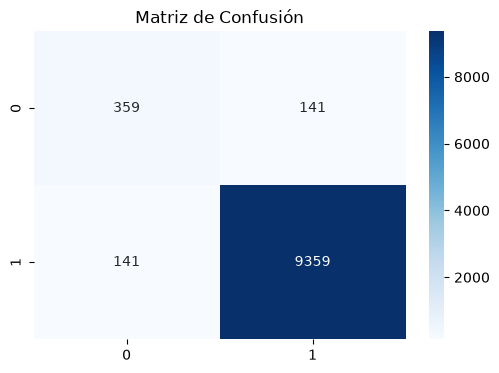

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Normalización
features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['label'], errors='ignore')
scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)

# Entrenamiento
model = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
model.fit(df_scaled)
print("Modelo entrenado exitosamente.")

# Predicciones
preds = model.predict(df_scaled)
y_true = df['label'].map({'normal': 1, 'anomaly': -1})

# Resultados
print("\nReporte de Clasificación:")
print(classification_report(y_true, preds))

# Gráfica de matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

In [6]:
import joblib

# Guardar ambos objetos
joblib.dump(model, 'modelo_anomalias.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Modelo y Scaler exportados como .pkl")

Modelo y Scaler exportados como .pkl


In [9]:
# En lugar de usar if __name__ == "__main__":
# Llama a la función directamente con el nombre del archivo:

archivo_a_analizar = 'network_traffic.csv'
predecir(archivo_a_analizar)

          src_ip           dst_ip  prediccion
38    10.0.1.238   185.220.101.45          -1
93     10.0.2.73       10.0.1.206          -1
139    10.0.2.73   185.220.101.45          -1
143   10.0.0.136       10.0.1.180          -1
176   10.0.1.220   185.220.101.45          -1
...          ...              ...         ...
9923  10.0.1.238  169.241.215.176          -1
9925  10.0.1.180      55.56.35.72          -1
9927  10.0.2.118    193.32.162.55          -1
9973   10.0.1.97       10.0.1.238          -1
9995  10.0.2.194   173.131.16.131          -1

[500 rows x 3 columns]


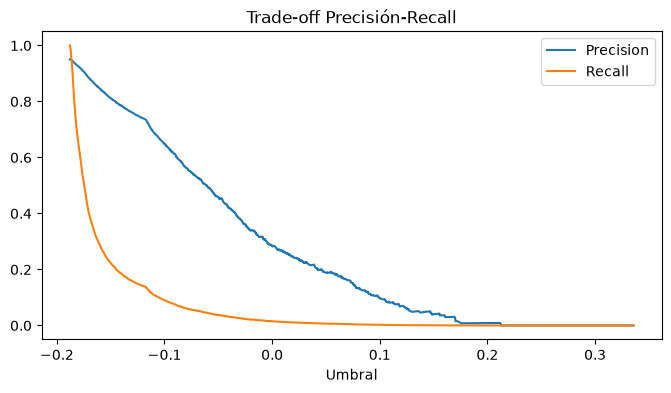

In [11]:
from sklearn.metrics import precision_recall_curve

# Obtener los scores de decisión (más negativo = más anómalo)
scores = model.decision_function(df_scaled)

precision, recall, thresholds = precision_recall_curve(y_true, -scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Umbral')
plt.legend()
plt.title('Trade-off Precisión-Recall')
plt.show()